DataGathering of family history data

In [ ]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math

from neurostatx.io.loader import DatasetLoader


In [2]:
# Setting up relevant paths
repository_path = "c:/Users/Rosalie/OneDrive - Office 365/Documents/UdeS/Hiver 2026/Crédits de recherche/GitHub/FuzzyClustering-PING"
ping_raw_data_dir = "c:/Users/Rosalie/OneDrive - Office 365/Documents/UdeS/Hiver 2026/Crédits de recherche/data/"
ping_cfa_data_dir = "c:/Users/Rosalie/OneDrive - Office 365/Documents/UdeS/Hiver 2026/Crédits de recherche/result/preprocessing/PING_CFA_Apply/"
output_dir = "c:/Users/Rosalie/OneDrive - Office 365/Documents/UdeS/Hiver 2026/Crédits de recherche/result/datagathering/familyhistory/"

# Create output directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [3]:
ping_cfa = pd.read_excel(f"{ping_cfa_data_dir}/transformed_dataset.xlsx")

df = DatasetLoader()
df = df.load_data(f"{ping_raw_data_dir}/PINGTabularData/fdh01.txt")
df = df.get_data()

c:\Users\Rosalie\OneDrive - Office 365\Documents\UdeS\Hiver 2026\Crédits de recherche\GitHub\FuzzyClustering-PING\.venv\Lib\site-packages\neurostatx\io\loader.py:80: DtypeWarning: Columns (0,1,2,6,10,11,13,14,16,17,18,19,20,21,22,24,25,26,27,28,29,30,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,54,55,56,57,58,59,60,68,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,2

In [4]:
# Regroup parents history together
parents_cols = [col for col in df.columns if col.endswith("_prnts")]
df_parents = df[["subjectkey"] + parents_cols]

# Regroup immediate family member history together
immediate_cols = [col for col in df.columns if col.endswith("_immed")]
df_immediate = df[["subjectkey", "hi_bipolar1"] + immediate_cols]

# Regroupe total family member history together
total_cols = [col for col in df.columns if col.endswith("_total")]
df_total = df[["subjectkey"] + total_cols]

In [ ]:
def clean_family_df(df, id_col="subjectkey"):
    # Garder la première ligne (descriptives) telle quelle
    desc_row = df.iloc[[0]]          # DataFrame avec 1 ligne
    data = df.iloc[1:].copy()        # Toutes les vraies observations (sujets)

    # Choisir les colonnes à nettoyer (tout sauf l'ID)
    cols_to_num = [c for c in data.columns if c != id_col]

    # Convertir en numérique 
    data[cols_to_num] = data[cols_to_num].apply(
        pd.to_numeric, errors="coerce"
    )

    # Retirer les sujets où TOUT est manquant dans ces colonnes
    mask_all_missing = data[cols_to_num].isna().all(axis=1)
    data = data[~mask_all_missing]

    # Recoller la ligne descriptive au-dessus
    df_clean = pd.concat([desc_row, data], axis=0)

    #  réindexer 
    df_clean = df_clean.reset_index(drop=True)

    return df_clean
 # Appliquer la fonction de nettoyage à chaque DataFrame
df_parents_clean   = clean_family_df(df_parents,   id_col="subjectkey")
df_immediate_clean = clean_family_df(df_immediate, id_col="subjectkey")
df_total_clean     = clean_family_df(df_total,     id_col="subjectkey")

In [ ]:
# Extract subjectkey of pind_cfa data
valid_ids = ping_cfa["subjectkey"].astype(str)

# Remove participant with no cognitive test in the family history dataframe
df_parents_filtered = df_parents_clean[
    df_parents_clean["subjectkey"].astype(str).isin(valid_ids)
]

df_immediate_filtered = df_immediate_clean[
    df_immediate_clean["subjectkey"].astype(str).isin(valid_ids)
]

df_total_filtered = df_total_clean[
    df_total_clean["subjectkey"].astype(str).isin(valid_ids)
]

In [9]:
# Sécurité : vérifier l’alignement des subjectkey
if not np.array_equal(
    df_parents_filtered["subjectkey"].values,
    df_immediate_filtered["subjectkey"].values
):
    raise ValueError("subjectkey non alignés entre parents et immediate")

if not np.array_equal(
    df_immediate_filtered["subjectkey"].values,
    df_total_filtered["subjectkey"].values
):
    raise ValueError("subjectkey non alignés entre immediate et total")

In [ ]:
# Copies de sécurité pour faire les ajustements
df_otherimmed_adj = df_immediate_filtered.copy()   # deviendra "autres membres immédiats"
df_extended_adj = df_total_filtered.copy()       # deviendra "famille étendue"

# Dictionnaire pour faire les calculs de séparation parents vs autres immédiats vs famille étendue
var_roots = {
    "alcool":          "fdh_40b_alcl_prb",
    "drug":            "fdh_40c_drug_prb",
    "stroke_tia":      "fdh_40d_stroke_tia",
    "hypertension":    "fdh_40e_htn_med",
    "alzheimer":       "fdh_40f_alzheimers",
    "parkinson":       "fdh_40g_parkinsons",
    "memory":          "fdh_40i_mem_prb",
    "migraine":        "fdh_40j_frq_hache",
    "seizures":        "fdh_40k_seizures",
    "depress_anxiety": "fdh_40l_dprs_anxi",
    "mentalretard_down": "fdh_40n_mntret_dwn",
    "schizo":          "fdh_40o_schizo",
    "learning":        "fdh_40p_lrn_prb",
    "adhd":            "fdh_40q_adhd",
    "juvdiabete":      "fdh_40r_juv_diabe",
    "braincancer":     "fdh_40s_brain_cncr",
}

# Soustraction pour tous les troubles qui ont prnts / immed / total
for short, root in var_roots.items():
    col_p = f"{root}_prnts"
    col_i = f"{root}_immed"
    col_t = f"{root}_total"

    # immediate_other = immed_raw - parents_raw
    if col_i in df_otherimmed_adj.columns and col_p in df_parents_filtered.columns:
        df_otherimmed_adj[col_i] = (
            df_immediate_filtered[col_i] - df_parents_filtered[col_p]
        ).clip(lower=0)

    # extended = total_raw - immed_raw
    if col_t in df_extended_adj.columns and col_i in df_immediate_filtered.columns:
        df_extended_adj[col_t] = (
            df_total_filtered[col_t] - df_immediate_filtered[col_i]
        ).clip(lower=0)

# Cas particulier : bipolar (pas dispo pour parents, noms différents)
# -> on ne peut PAS séparer parents vs autres immédiats
#    donc on garde hi_bipolar1 tel quel pour immediate
#    et on crée "extended" = total - immediate

if "fdh_40m_bipolar_total" in df_extended_adj.columns and "hi_bipolar1" in df_otherimmed_adj.columns:
    df_extended_adj["fdh_40m_bipolar_total"] = (
        df_total_filtered["fdh_40m_bipolar_total"] - df_immediate_filtered["hi_bipolar1"]
    ).clip(lower=0)


def build_family_table(df_filtered, suffix, level_name="prnts", bipolar_col=None):

    vars_full = ["subjectkey"]
    rename_cols = ["subjectkey"]
    
    for short, root in var_roots.items():
        full_name = f"{root}_{suffix}" 
        if full_name in df_filtered.columns:
            vars_full.append(full_name)
            rename_cols.append(f"{short}_{level_name}")

# Add bipolar (because it is not available for parents only)
    if bipolar_col is not None and bipolar_col in df_filtered.columns:
        vars_full.append(bipolar_col)
        rename_cols.append(f"bipolar_{level_name}")

# Extract and rename
    fam = df_filtered[vars_full].copy()
    fam.columns = rename_cols

# Create categorie groups (0 = 0 person, 1 = at least 1 person, 2 = at least 2 persons, 3 = at least 3 persons)
    cols_to_group = [c for c in fam.columns if c != "subjectkey"]
    fam[cols_to_group] = fam[cols_to_group].clip(upper=3)

# Create categories for each problem type by taking the max of the relevant columns 
# Neurodevelopmental problems
    fam.loc[:, f"neurodevelop_{level_name}"] = fam[
        [f"learning_{level_name}", f"adhd_{level_name}", f"mentalretard_down_{level_name}"]
    ].fillna(0).max(axis=1)
 
 # Psychologic problems
    psych_cols = [f"depress_anxiety_{level_name}", f"schizo_{level_name}"]
    if f"bipolar_{level_name}" in fam.columns:
        psych_cols.append(f"bipolar_{level_name}")
    fam.loc[:, f"psychiatric_{level_name}"] = fam[psych_cols].fillna(0).max(axis=1)

# Neurologic problems
    fam.loc[:, f"neurologic_{level_name}"] = fam[
        [f"seizures_{level_name}", f"migraine_{level_name}", f"braincancer_{level_name}"]
    ].fillna(0).max(axis=1)

# Neurodegenerative problems
    fam.loc[:, f"neurodegenerative_{level_name}"] = fam[
        [f"alzheimer_{level_name}", f"parkinson_{level_name}", f"memory_{level_name}"]
    ].fillna(0).max(axis=1)

# Vascular or metabolic problems
    fam.loc[:, f"vasc_metabo_{level_name}"] = fam[
        [f"stroke_tia_{level_name}", f"hypertension_{level_name}", f"juvdiabete_{level_name}"]
    ].fillna(0).max(axis=1)

# Substances use problems
    fam.loc[:, f"substance_{level_name}"] = fam[
        [f"alcool_{level_name}", f"drug_{level_name}"]
    ].fillna(0).max(axis=1)

    return fam

# Apply to parents, other immediate and extended family data
fam_parents_data = build_family_table(
    df_parents_filtered,
    suffix="prnts",
    level_name="prnts",
    bipolar_col=None,  
)

fam_otherimmed_data = build_family_table(
    df_otherimmed_adj,
    suffix="immed",
    level_name="otherimmed",
    bipolar_col="hi_bipolar1",
)

fam_extended_data = build_family_table(
    df_extended_adj,
    suffix="total",
    level_name="extended",
    bipolar_col="fdh_40m_bipolar_total",
)


C:\Users\Rosalie\AppData\Local\Temp\ipykernel_7764\398524802.py:81: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ].fillna(0).max(axis=1)
C:\Users\Rosalie\AppData\Local\Temp\ipykernel_7764\398524802.py:87: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  fam.loc[:, f"psychiatric_{level_name}"] = fam[psych_cols].fillna(0).max(axis=1)
C:\Users\Rosalie\AppData\Local\Temp\ipykernel_7764\398524802.py:92: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=Fals

In [ ]:
# Calcul du total brut 
fam_total_data = fam_parents_data[["subjectkey"]].copy()

# Catégories 
cat_roots = [
    "neurodevelop",
    "psychiatric",
    "neurologic",
    "neurodegenerative",
    "vasc_metabo",
    "substance",
]
# On fait la somme des 3 niveaux pour chaque catégorie
for cat in cat_roots:
    fam_total_data[f"{cat}_total"] = (
        fam_parents_data[f"{cat}_prnts"].fillna(0)
        + fam_otherimmed_data[f"{cat}_otherimmed"].fillna(0)
        + fam_extended_data[f"{cat}_extended"].fillna(0)
    )
    
# Create categorie groups (0 = 0 person, 1 = at least 1 person, 2 = at least 2 persons, 3 = at least 3 persons)
for cat in cat_roots:
    fam_total_data[f"{cat}_total"] = fam_total_data[f"{cat}_total"].clip(upper=3)

# Colonnes à garder dans chaque tableau
parents_keep = ["subjectkey"] + [f"{c}_prnts"    for c in cat_roots] # parents
otherimmed_keep   = ["subjectkey"] + [f"{c}_otherimmed"    for c in cat_roots]  # other immediate
extended_keep     = ["subjectkey"] + [f"{c}_extended"    for c in cat_roots]  # extended 
total_keep     = ["subjectkey"] + [f"{c}_total" for c in cat_roots]  # total brut

# On réduit chaque tableau aux colonnes qui nous intéressent
df_parents = fam_parents_data[parents_keep].copy()
df_otherimmed = fam_otherimmed_data[otherimmed_keep].copy()
df_extended = fam_extended_data[extended_keep].copy()
df_total = fam_total_data[total_keep].copy()

# Merge successifs sur subjectkey
fam_all = (
    df_parents
    .merge(df_otherimmed, on="subjectkey", how="inner")
    .merge(df_extended, on="subjectkey", how="inner")
    .merge(df_total, on="subjectkey", how="inner")
)

fam_all.to_excel(f"{output_dir}/family_history_categories_all_levels.xlsx", index=False)


In [ ]:
# Correlation de spearman entre variables cognitives et familiales (avec les catégories totales pour les troubles familiaux)
data_all = ping_cfa.merge(fam_all, on="subjectkey", how="inner")

cog_vars = ["VA", "EFPS", "MEM"]
fam_vars = [f"{c}_total" for c in cat_roots]

df_corr = data_all[cog_vars + fam_vars]

corr_sub = df_corr[cog_vars + fam_vars].corr(method="spearman").loc[cog_vars, fam_vars]


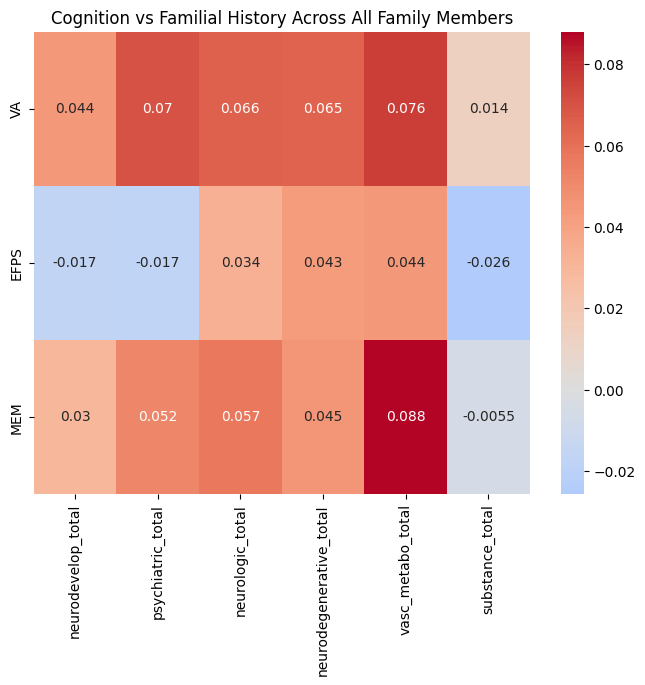

In [ ]:
# Visualisation en heatmap des corrélations
plt.figure(figsize=(8,6))
rename_dict = {
    "neurodevelop_total": "Neurodevelopmental history",
    "psychiatric_total": "Psychiatric history",
    "neurologic_total": "Neurologic history",
    "neurodegenerative_total": "Neurodegenerative history",
    "vasc_metabo_total": "Vascular/Metabolic history",
    "substance_total": "Substance use history"
}
corr_sub_renamed = corr_sub.rename(columns=rename_dict)
sns.heatmap(corr_sub, annot=True, cmap="coolwarm", center=0)
plt.title("Cognition vs Familial History Across All Family Members")
plt.show()

In [ ]:
# Correlation de spearman entre variables cognitives et familiales (parents)
fam_vars_parents = [f"{c}_prnts" for c in cat_roots]

df_corr_parents = data_all[cog_vars + fam_vars_parents]

corr_sub_parents = df_corr_parents[cog_vars + fam_vars_parents].corr(method='spearman').loc[cog_vars, fam_vars_parents]

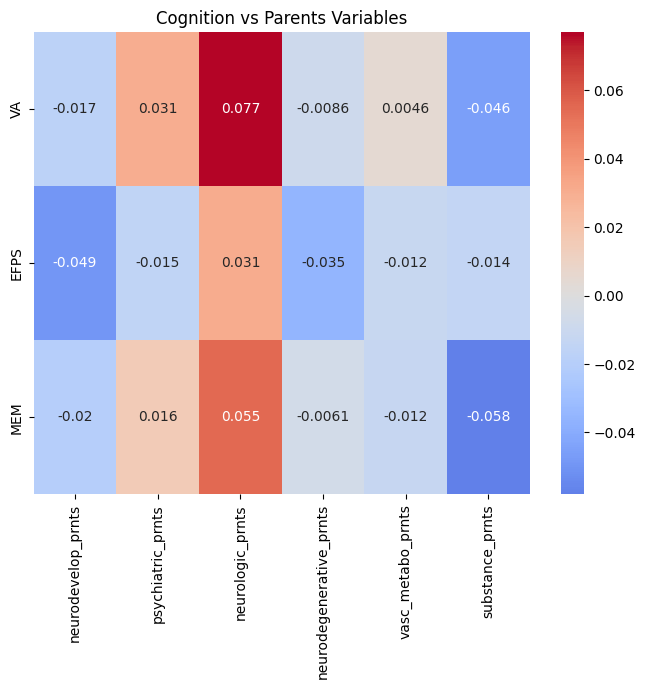

In [ ]:
# Visualisation en heatmap des corrélations
plt.figure(figsize=(8,6))
sns.heatmap(corr_sub_parents, annot=True, cmap="coolwarm", center=0)
plt.title("Cognition vs Parents Variables")
plt.show()

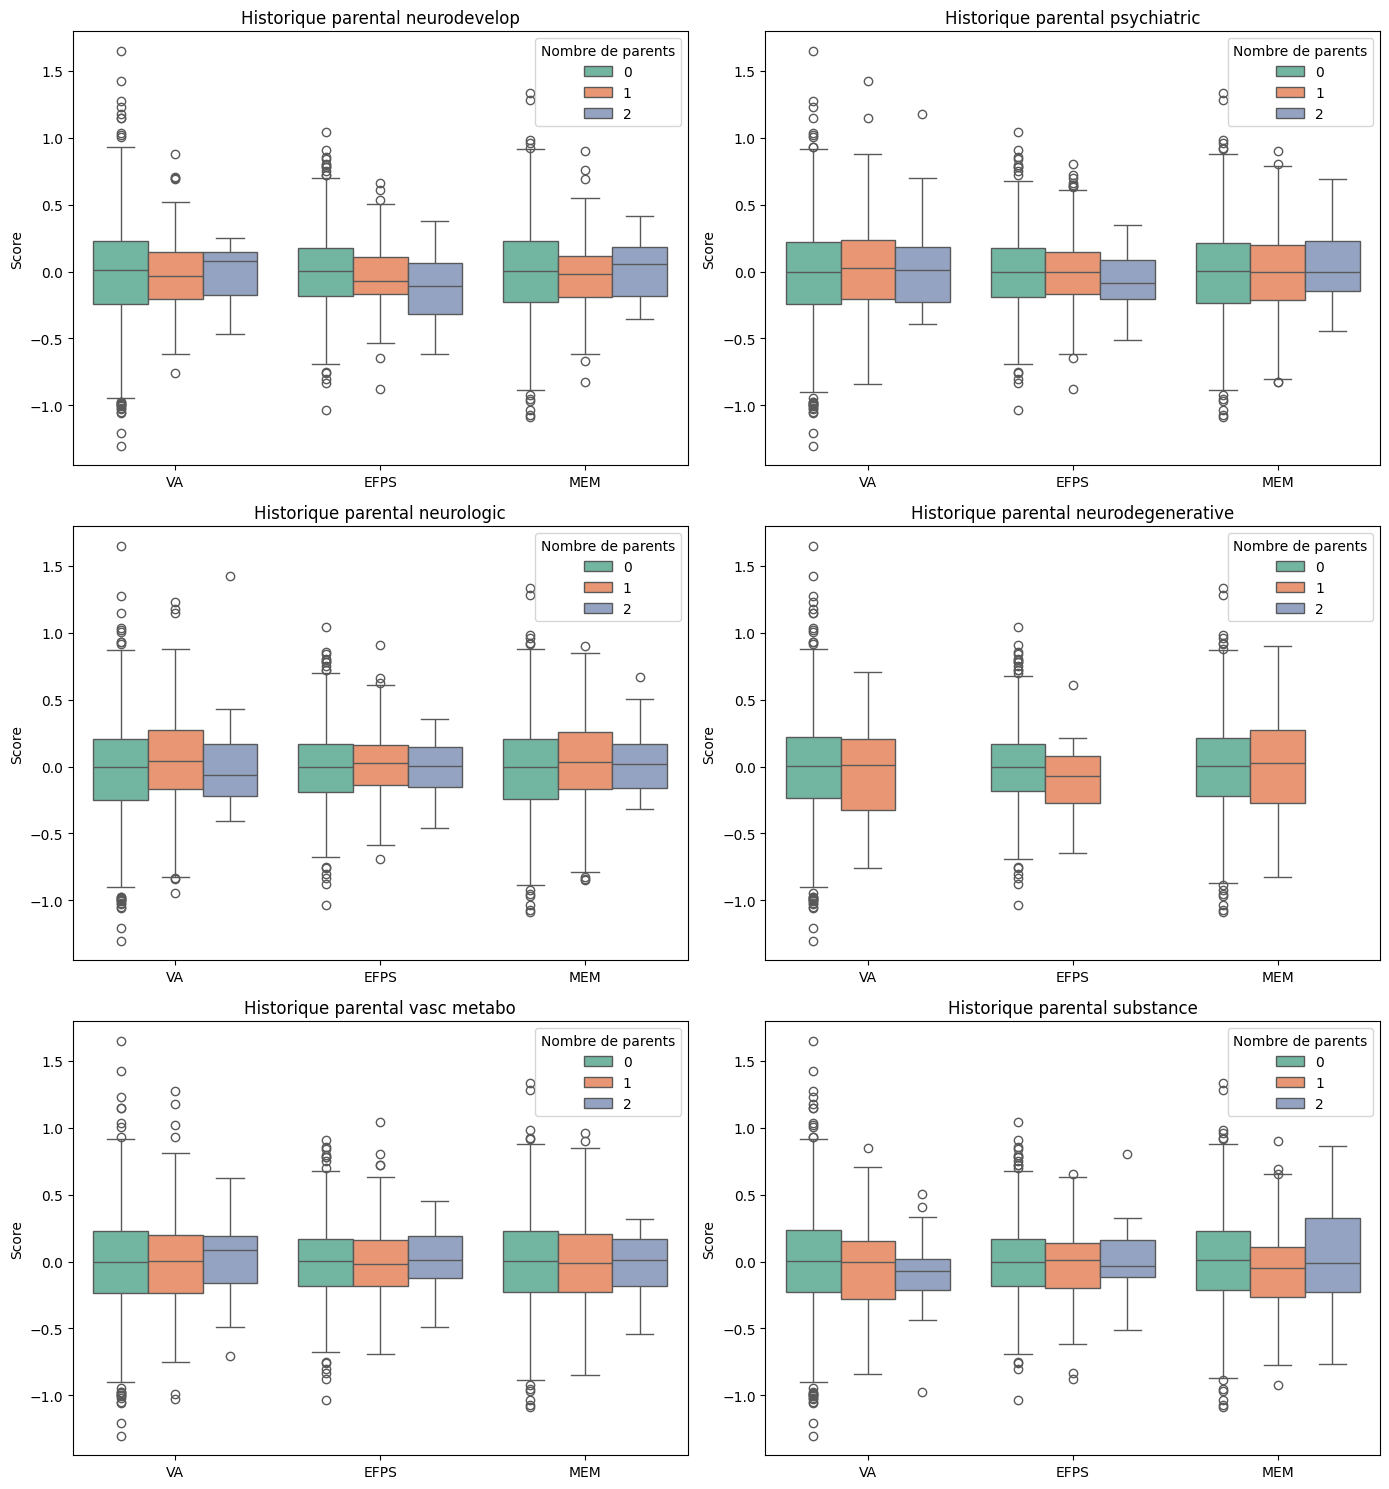

In [ ]:
# Visualisation en boxplots des scores cognitifs selon l'historique familial (parents)

# Colonnes cognitives et parentales
cog_vars = ["VA", "EFPS", "MEM"]
parent_cols = [c for c in data_all.columns if c.endswith("_prnts")]

n = len(parent_cols)
ncols = 2
nrows = math.ceil(n / ncols)

# Créer une figure avec des sous-graphiques pour chaque variable parentale
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 5*nrows))
axes = axes.flatten()

for i, col in enumerate(parent_cols):
    data_long = data_all.melt(
        id_vars=col,
        value_vars=cog_vars,
        var_name="Cognitive_test",
        value_name="Score"
    )

    sns.boxplot(
        data=data_long,
        x="Cognitive_test",
        y="Score",
        hue=col,
        palette="Set2",
        hue_order=[0,1,2],
        ax=axes[i]
    )

    replace_parents = col.replace("_prnts", "").replace("_", " ")

    axes[i].set_title(f"Historique parental {replace_parents}")
    axes[i].set_ylabel("Score")
    axes[i].set_xlabel("")
    axes[i].legend(title="Nombre de parents")


plt.tight_layout()
plt.savefig(f"{output_dir}boxplots_historique_parental_cognitifs.png", dpi=300, bbox_inches="tight")
plt.show()

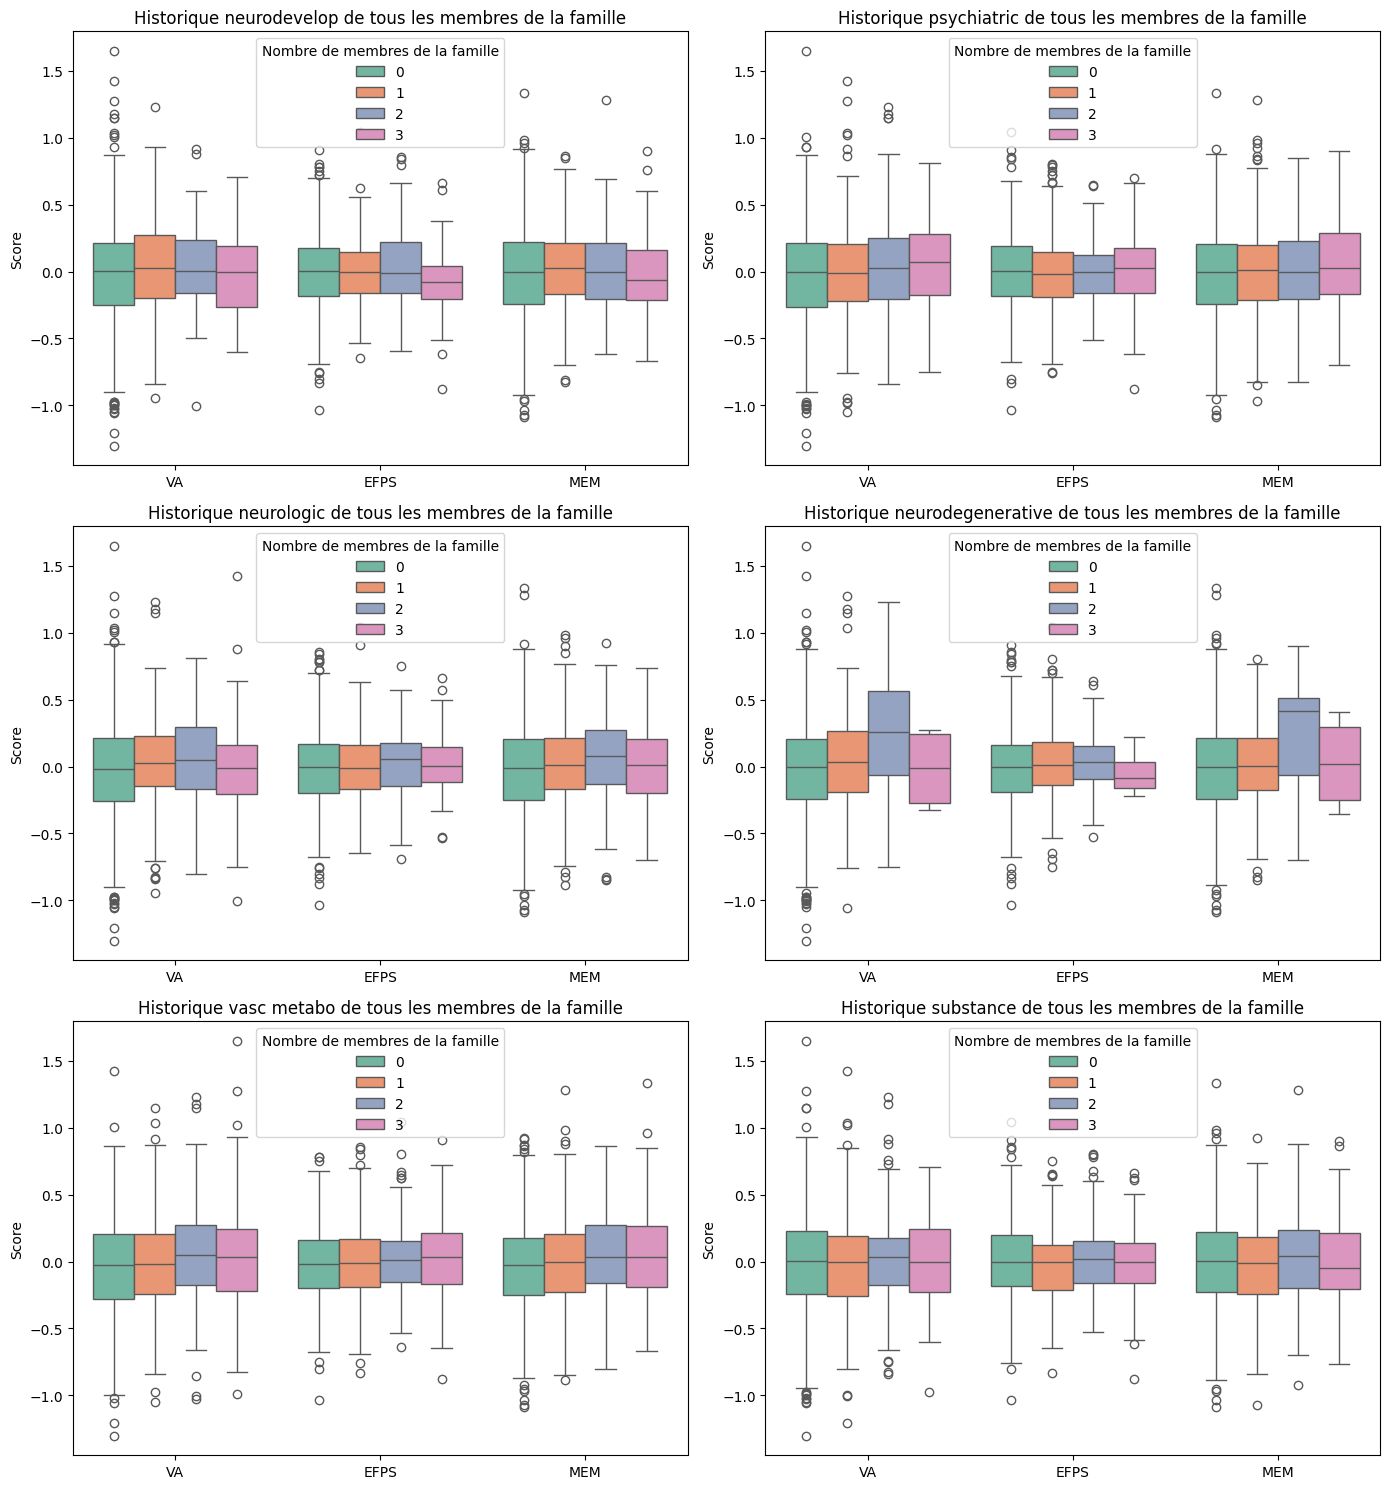

In [ ]:
# Visualisation en boxplots des scores cognitifs selon l'historique familial (tous les membres de la famille)

# Colonnes totales pour tous les membres de la famille
total_cols = [c for c in data_all.columns if c.endswith("_total")]

n = len(total_cols)
ncols = 2
nrows = math.ceil(n / ncols)

# Créer une figure avec des sous-graphiques pour chaque variable totale
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 5*nrows))
axes = axes.flatten()


for i, col in enumerate(total_cols):
    data_long = data_all.melt(
        id_vars=col,
        value_vars=cog_vars,
        var_name="Cognitive_test",
        value_name="Score"
    )

    sns.boxplot(
        data=data_long,
        x="Cognitive_test",
        y="Score",
        hue=col,
        palette="Set2",
        hue_order=[0,1,2,3],
        ax=axes[i]
    )

    pretty = col.replace("_total", "").replace("_", " ")

    axes[i].set_title(f"Historique {pretty} de tous les membres de la famille")
    axes[i].set_ylabel("Score")
    axes[i].set_xlabel("")
    axes[i].legend(title="Nombre de membres de la famille")

plt.tight_layout()
plt.savefig(f"{output_dir}boxplots_historique_total_cognitifs.png", dpi=300, bbox_inches="tight")
plt.show()